# ML for solid mechanics and computational homogenization

## Objectives

1. Learn how to use basic tools of Machine Learning (ML) within the context of solid mechanics and materials modelling.
2. Learn to apply MultiLayer Perceptron (MLP) and Convolutional Neural Network (CNN).
3. Learn to regress stress-strain curve in 2D of a hyperelastic material.
4. Learn to regress effective stiffness tensor of arbitrary microstructure from Representative Volume Element (RVE) simulations represented as a BW image.

Exercises below require installations of VS code (recommended) and python with pytorch on your laptop.

In this JuPyther notebook, missing parts that need to be supplemented by students are indicated as $\dots\ = []; \% FIX$. Other parts of the provided implementation do not need to be adjusted, but should be well understood by students to achieve the set objectives of these exercises. Optional or more challenging exercises are denoted with an asterisk $\star$.

## 1. Basics of ML: pytorch, tensors, and backprop

This exercise uses pytorch as the main implementation environment. For basic introduction to pytorch click on the following link: https://docs.pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html.

In particular, revise sections on "Tensors" and "A gentle introduction to torch.autograd".

## 2. Regression of a hyperelastic constitutive law

Consider a known explicit Bertoldi-Boyce hyperelastic constitutive law in two-dimensional setting under plane strain assumption, given by its energy density as
$$
W(\boldsymbol{F}) = C_1(I_1-3)+C_2(I_1-3)^2-2C_1\log(J)+\frac{1}{2}K(J-1)^2,
$$
where $\boldsymbol{F}(\vec{X}) = \boldsymbol{I} + (\vec{\nabla}\vec{u}(\vec{X}))^\mathsf{T}$ is the deformation gradient, $\boldsymbol{I} = \sum_{i=1}^3\vec{e}_i\vec{e}_i$ is the identity tensor with respect to a selected Cartesian coordinate basis $\{ \vec{e}_1, \vec{e}_2, \vec{e}_3 \}$, $\vec{\nabla} = \sum_{i=1}^3\frac{\partial}{\partial X_i}\vec{e}_i$ is the gradient operator with respect to the reference configuration, $\vec{u}(\vec{X})$ the displacement field, $I_1 = \mathrm{tr}{\boldsymbol{C}}$ is the first invariant of the right Cauchy-Green deformation tensor $\boldsymbol{C} = \boldsymbol{F}^\mathsf{T}\cdot\boldsymbol{F}$, $\boldsymbol{A}\cdot\boldsymbol{B}$ denotes contraction between two second-order tensors, $J = \det{\boldsymbol{F}}$, and $C_1$, $C_2$, and $K$ are material constants. 

For hyperelastic materials, the corresponding first Piola-Kirchhoff (1PK) stress and its constitutive tangent are obtained from the energy density potential above as
$$
\boldsymbol{P}(\boldsymbol{F}) = \frac{\partial W(\boldsymbol{F})}{\partial\boldsymbol{F}},
$$
$$
^{4}\boldsymbol{D}(\boldsymbol{F}) = \frac{\partial^2 W(\boldsymbol{F})}{\partial\boldsymbol{F}\partial\boldsymbol{F}} = \frac{\partial\boldsymbol{P}(\boldsymbol{F})}{\partial\boldsymbol{F}},
$$
which, in component form, read as
$$
P_{ij} = \frac{\partial W}{\partial F_{ij}} = 2C_1F_{ij}+4C_2(I_1-3)F_{ij}-2C_1F^{-1}_{ji}+K(J-1)JF^{-1}_{ji}
$$
$$
D_{ijkl} = \frac{\partial^2W}{\partial F_{ij}\partial F_{kl}} = \frac{\partial P_{ij}}{\partial F_{kl}} = 2C_1\delta_{ik}\delta_{jl}+8C_2F_{kl}F_{ij}+4C_2(I_1-3)\delta_{ik}\delta_{jl}+
2C_1F^{-1}_{li}F^{-1}_{jk}+KJ^2F^{-1}_{ji}F^{-1}_{lk}+KJ(J-1)F^{-1}_{ji}F^{-1}_{lk}-KJ(J-1)F^{-1}_{li}F^{-1}_{jk}.
$$

The energy density, 1PK stress, and corresponding constitutive stiffness are provided as an explicit function as well as in the available training dataset, expressed as a function of the deformation gradient.

In [ ]:
# Import libraries
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

### Example 2.1

This example does not require adjustments of any code, but rather serves as a demonstration of the main basic building blocks and typical training procedure present in any ML code:
1. Define a neural network that has learnable parameters (or weights)
2. Iterate over a dataset of inputs
3. Process input through the network
4. Compute the loss (how far is the output from being correct)
5. Propagate gradients back into the network’s parameters
6. Update the weights of the network, typically using a simple update rule.

Using a MultiLayer Perceptron (MLP) type of neural network, we will perform a regression of the 1PK stress tensor as a function of the deformation gradient, i.e., $\boldsymbol{P}(\boldsymbol{F}) \approx \mathsf{MLP}(\boldsymbol{F})$.

#### 0. Open dataset

In [ ]:
# load data
data_path = 'BertoldiBoyce_dataset.pt'
data = torch.load(data_path)

# Preprocess data: reshape to be 2D (num_samples, num_features)
F = data['F'].to(torch.float32).flatten(start_dim=1)
W = data['W'].to(torch.float32).unsqueeze(-1)
P = data['P'].to(torch.float32).flatten(start_dim=1)
D = data['D'].to(torch.float32).flatten(start_dim=1)

num_samples = F.shape[0]

print(f"F shape: {F.shape}")
print(f"W shape: {W.shape}")
print(f"P shape: {P.shape}")
print(f"D shape: {D.shape}")
print(f"Number of samples: {num_samples}")

F shape: torch.Size([1000, 4])
W shape: torch.Size([1000, 1])
P shape: torch.Size([1000, 4])
D shape: torch.Size([1000, 16])
Number of samples: 1000


In [ ]:
# Split into train/val/test
train_ratio = 0.7
val_ratio = 0.15

train_size = int(train_ratio * num_samples)
val_size = int(val_ratio * num_samples)

split_seed = 42
generator = torch.Generator().manual_seed(split_seed)
indices = torch.randperm(num_samples, generator=generator)
train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

F_train, F_val, F_test = F[train_idx], F[val_idx], F[test_idx]
W_train, W_val, W_test = W[train_idx], W[val_idx], W[test_idx]
P_train, P_val, P_test = P[train_idx], P[val_idx], P[test_idx]
D_train, D_val, D_test = D[train_idx], D[val_idx], D[test_idx]

train_data = torch.cat([F_train, W_train, P_train, D_train], dim=1)
val_data = torch.cat([F_val, W_val, P_val, D_val], dim=1)
test_data = torch.cat([F_test, W_test, P_test, D_test], dim=1)


In [ ]:
# Standardize features using training set statistics
mean = train_data.mean(dim=0, keepdim=True)
std = train_data.std(dim=0, keepdim=True)

train_data_scaled = (train_data - mean) / std
val_data_scaled = (val_data - mean) / std
test_data_scaled = (test_data - mean) / std

batch_size = 64
train_loader = DataLoader(train_data_scaled, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data_scaled, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data_scaled, batch_size=batch_size, shuffle=False)

first_batch = next(iter(train_loader))
print('Example batch shape:', first_batch.shape)

Example batch shape: torch.Size([64, 25])


Each batch now consists of 64 samples, each of which has 25 features: the first four are the scaled entries of F, the fifth entry is the scaled W, the next four are the scaled P and the last 16 are the scaled D.

#### 1. Define a neural network that has learnable parameters (or weights)
This network will map F to P.

In [ ]:
input_dim = 4
output_dim = 4
hidden_dim = 64

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, output_dim),
)

print(model)

Sequential(
  (0): Linear(in_features=4, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=4, bias=True)
)


#### 2. Iterate over a dataset of inputs


In [ ]:
# We only use F as input and P as target in this example.
# In each batch, the columns are ordered as [F(4), W(1), P(4), D(16)].

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 100

# ------------------------------------------------------------------
# First: we show one single training step in detail
# ------------------------------------------------------------------
example_batch = next(iter(train_loader))
example_inputs = example_batch[:, 0:4]
example_targets = example_batch[:, 5:9]

print('One batch from the dataloader has shape:', tuple(example_batch.shape))
print('Input batch F has shape:', tuple(example_inputs.shape))
print('Target batch P has shape:', tuple(example_targets.shape))

example_predictions = model(example_inputs)
example_loss = criterion(example_predictions, example_targets)

print('Prediction shape after the forward pass:', tuple(example_predictions.shape))
print('Loss before the update step:', example_loss.item())

optimizer.zero_grad()
example_loss.backward()
optimizer.step()

new_loss = criterion(model(example_inputs), example_targets)
print('Loss after one update step:', new_loss.item())


One batch from the dataloader has shape: (64, 25)
Input batch F has shape: (64, 4)
Target batch P has shape: (64, 4)
Prediction shape after the forward pass: (64, 4)
Loss before the update step: 1.4442754983901978
Loss after one update step: 1.4282300472259521


In [ ]:
# ------------------------------------------------------------------
# Now perform the full training loop.
# ------------------------------------------------------------------
train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    model.train()  # put model in training mode (not important here, but a good habit because it's important if you have layers like dropout or batchnorm)

    train_loss_sum = 0.0

    # Train on all training data
    for batch in train_loader:
        inputs = batch[:, 0:4]
        targets = batch[:, 5:9]

        predictions = model(inputs)
        loss = criterion(predictions, targets)

        # Set all gradients to zero
        optimizer.zero_grad()

        # Backpropagate to compute gradients
        loss.backward()

        # Update model parameters using the optimizer
        optimizer.step()

        train_loss_sum += loss.item() * inputs.shape[0]

    mean_train_loss = train_loss_sum / len(train_loader.dataset)
    train_loss_history.append(mean_train_loss)

    model.eval()  # put model in evaluation mode
    val_loss_sum = 0.0

    # Check performance on the validation data
    with torch.inference_mode():
        for batch in val_loader:
            inputs = batch[:, 0:4]
            targets = batch[:, 5:9]

            predictions = model(inputs)
            loss = criterion(predictions, targets)
            val_loss_sum += loss.item() * inputs.shape[0]

    mean_val_loss = val_loss_sum / len(val_loader.dataset)
    val_loss_history.append(mean_val_loss)

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(
            f'Epoch {epoch + 1:3d}/{num_epochs} | '
            f'train loss = {mean_train_loss:.6f} | '
            f'val loss = {mean_val_loss:.6f}'
        )


Epoch   1/100 | train loss = 0.951373 | val loss = 0.792989
Epoch  10/100 | train loss = 0.015254 | val loss = 0.011922
Epoch  20/100 | train loss = 0.004765 | val loss = 0.003294
Epoch  30/100 | train loss = 0.002459 | val loss = 0.002258
Epoch  40/100 | train loss = 0.001702 | val loss = 0.001901
Epoch  50/100 | train loss = 0.001184 | val loss = 0.001237
Epoch  60/100 | train loss = 0.000953 | val loss = 0.000998
Epoch  70/100 | train loss = 0.000828 | val loss = 0.001033
Epoch  80/100 | train loss = 0.000900 | val loss = 0.000880
Epoch  90/100 | train loss = 0.000630 | val loss = 0.000716
Epoch 100/100 | train loss = 0.000578 | val loss = 0.000737


In [ ]:
# ------------------------------------------------------------------
# Evaluate the trained model on the test set.
# ------------------------------------------------------------------
model.eval()
test_loss_sum = 0.0
preds = []
targets = []

with torch.inference_mode():
    for batch in test_loader:
        inputs = batch[:, 0:4]
        target = batch[:, 5:9]

        pred = model(inputs)
        loss = criterion(pred, target)

        test_loss_sum += loss.item() * inputs.shape[0]
        preds.append(pred)
        targets.append(target)

mean_test_loss = test_loss_sum / len(test_loader.dataset)
preds = torch.cat(preds, dim=0)
targets = torch.cat(targets, dim=0)

print(f'Final test loss = {mean_test_loss:.6f}')


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x4 and 3x64)

In [ ]:

# ------------------------------------------------------------------
# Plot how the training and validation losses change with epoch.
# ------------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(train_loss_history, label='train loss')
plt.plot(val_loss_history, label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.yscale('log')
plt.title('Training history')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

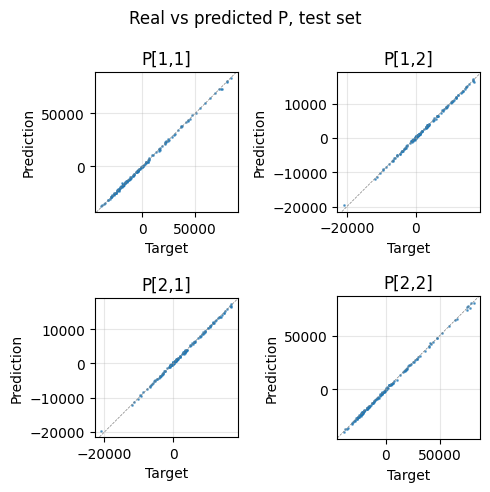

In [ ]:
# ------------------------------------------------------------------
# Cross-plots: predicted P versus target P on the test set.
# The network predicts scaled P, so we first transform it back to the
# original physical scale before comparing against the raw test targets.
# ------------------------------------------------------------------
P_mean = mean[:, 5:9]
P_std = std[:, 5:9]

preds_unscaled = preds * P_std + P_mean
preds_unscaled = preds_unscaled.reshape(-1, 2, 2)
targets_unscaled = P_test.reshape(-1, 2, 2)

fig, axes = plt.subplots(2, 2, figsize=(5, 5))
for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        target_component = targets_unscaled[:, i, j].detach().cpu().numpy()
        prediction_component = preds_unscaled[:, i, j].detach().cpu().numpy()

        ax.scatter(target_component, prediction_component, s=1, alpha=0.6)
        ax.axline([0,0], slope=1, color='gray', linestyle='--', linewidth=0.5)

        ax.set_title(f'P[{i+1},{j+1}]')
        ax.set_xlabel('Target')
        ax.set_ylabel('Prediction')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

fig.suptitle('Real vs predicted P, test set')
plt.tight_layout()
plt.show()

### Exercise 2.2

In this exercise, you will take the first steps towards making changes in the existing NN. From an engineering perspective, more sensible way of fitting constitutive relations is to work with 2PK stress $\boldsymbol{S} = \boldsymbol{F}^{-1}\boldsymbol{P} \in \mathrm{Sym}$ and Green-Lagrange strain tensor $\boldsymbol{E} = \frac{1}{2}(\boldsymbol{C}-\boldsymbol{I}) \in \mathrm{Sym} $. The main advantage of this approach is that the quantities are "cleaned off" the rotation tensor and hence are symmetric, reducing the number of parameters that need to be regressed. This can be seen from the above expressions for $\boldsymbol{E}$ using polar decomposition $\boldsymbol{F} = \boldsymbol{R}\cdot\boldsymbol{U}$, where $\boldsymbol{R}$, $\boldsymbol{R}^\mathsf{T}\cdot\boldsymbol{R} = \boldsymbol{I}$, is the rotation tensor, and $\boldsymbol{U}$ the right stretch tensor. In addition to the stress-strain relations, this NN will predict also energy density $W$ on top of the 2PK stress $\boldsymbol{S}$, i.e., $\{ W, \boldsymbol{S} \} \approx \mathsf{MLP}(\boldsymbol{E})$.

In [ ]:
# Green-Lagrange strain tensor E = 0.5 * (C - I), where C = F^T F
F_mat = F.reshape(-1, 2, 2)
C = F_mat.transpose(1, 2) @ F_mat
I = torch.eye(2, dtype=F_mat.dtype, device=F_mat.device).unsqueeze(0)
E = 0.5 * (C - I)  # shape: [N, 2, 2]

# Compact vector form for symmetric 2x2 tensors: [E11, E22, E12]
E_vec = torch.stack([E[:, 0, 0], E[:, 1, 1], E[:, 0, 1]], dim=1)

# 2nd Piola-Kirchhoff stress S = F^{-1} P
P_mat = P.reshape(-1, 2, 2)
F_inv = torch.linalg.inv(F_mat)
S = F_inv @ P_mat  # shape: [N, 2, 2]

# Compact vector form for symmetric 2x2 tensors: [S11, S22, S12]
S_vec = torch.stack([S[:, 0, 0], S[:, 1, 1], S[:, 0, 1]], dim=1)

print('E shape:', tuple(E.shape))
print('E_vec shape:', tuple(E_vec.shape))
print('S shape:', tuple(S.shape))
print('S_vec shape:', tuple(S_vec.shape))
print('First sample E:\n', E[0])
print('First sample S:\n', S[0])

E shape: (1000, 2, 2)
E_vec shape: (1000, 3)
S shape: (1000, 2, 2)
S_vec shape: (1000, 3)
First sample E:
 tensor([[0.4737, 0.2677],
        [0.2677, 0.5194]])
First sample S:
 tensor([[ 56585.4453, -13946.5840],
        [-13946.5850,  54200.5781]])


In [ ]:
# Split S and E into train/val/test sets using the same indices as before
S_train, S_val, S_test = S_vec[train_idx], S_vec[val_idx], S_vec[test_idx]
E_train, E_val, E_test = E_vec[train_idx], E_vec[val_idx], E_vec[test_idx]

# New training data needs E, S, W. We keep F and P as well to compare against the previous model that only used F as input.
train_data = torch.cat([E_train, S_train, W_train, F_train, P_train], dim=1)
val_data =   torch.cat([E_val,   S_val,   W_val,   F_val,   P_val], dim=1)
test_data =  torch.cat([E_test,  S_test,  W_test,  F_test,  P_test], dim=1)

# In each batch, the columns are ordered as [E(3), S(3), W(1), F(4), P(4)].

In [ ]:
# Standardize features using training set statistics
mean = train_data.mean(dim=0, keepdim=True)
std = train_data.std(dim=0, keepdim=True)

train_data_scaled = (train_data - mean) / std
val_data_scaled = (val_data - mean) / std
test_data_scaled = (test_data - mean) / std

batch_size = 64
train_loader = DataLoader(train_data_scaled, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data_scaled, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data_scaled, batch_size=batch_size, shuffle=False)

first_batch = next(iter(train_loader))
print('Example batch shape:', first_batch.shape)

Example batch shape: torch.Size([64, 15])


In [ ]:
input_dim = 3
output_dim = 4  # W and S
hidden_dim = 128

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, output_dim),
)

print(model)

Sequential(
  (0): Linear(in_features=3, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=128, bias=True)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=4, bias=True)
)


In [ ]:
# ------------------------------------------------------------------
# Now perform the full training loop.
# ------------------------------------------------------------------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    model.train()  # put model in training mode (not important here, but a good habit because it's important if you have layers like dropout or batchnorm)

    train_loss_sum = 0.0

    # Train on all training data
    for batch in train_loader:
        inputs = batch[:, 0:3]
        targets = batch[:, 3:7]

        predictions = model(inputs)
        loss = criterion(predictions, targets)

        # Set all gradients to zero
        optimizer.zero_grad()

        # Backpropagate to compute gradients
        loss.backward()

        # Update model parameters using the optimizer
        optimizer.step()

        train_loss_sum += loss.item() * inputs.shape[0]

    mean_train_loss = train_loss_sum / len(train_loader.dataset)
    train_loss_history.append(mean_train_loss)

    model.eval()  # put model in evaluation mode
    val_loss_sum = 0.0

    # Check performance on the validation data
    with torch.inference_mode():
        for batch in val_loader:
            inputs = batch[:, 0:3]
            targets = batch[:, 3:7]

            predictions = model(inputs)
            loss = criterion(predictions, targets)
            val_loss_sum += loss.item() * inputs.shape[0]

    mean_val_loss = val_loss_sum / len(val_loader.dataset)
    val_loss_history.append(mean_val_loss)

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(
            f'Epoch {epoch + 1:3d}/{num_epochs} | '
            f'train loss = {mean_train_loss:.6f} | '
            f'val loss = {mean_val_loss:.6f}'
        )


Epoch   1/100 | train loss = 0.893612 | val loss = 0.472798
Epoch  10/100 | train loss = 0.173804 | val loss = 0.028837
Epoch  20/100 | train loss = 0.105341 | val loss = 0.015623
Epoch  30/100 | train loss = 0.084497 | val loss = 0.017361
Epoch  40/100 | train loss = 0.066977 | val loss = 0.054209
Epoch  50/100 | train loss = 0.052250 | val loss = 0.047324
Epoch  60/100 | train loss = 0.044650 | val loss = 0.008317
Epoch  70/100 | train loss = 0.031991 | val loss = 0.007972
Epoch  80/100 | train loss = 0.048778 | val loss = 0.025270
Epoch  90/100 | train loss = 0.018937 | val loss = 0.004407
Epoch 100/100 | train loss = 0.024159 | val loss = 0.022717


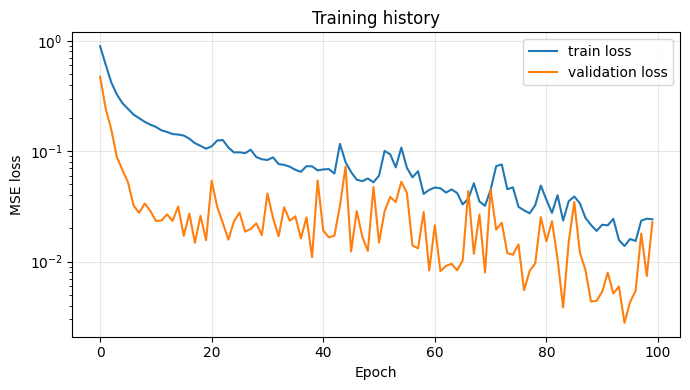

In [ ]:
# ------------------------------------------------------------------
# Plot how the training and validation losses change with epoch.
# ------------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(train_loss_history, label='train loss')
plt.plot(val_loss_history, label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.yscale('log')
plt.title('Training history')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Evaluate the trained model on the test set.
# ------------------------------------------------------------------
model.eval()
test_loss_sum = 0.0

preds = []
targets = []
targets_P = []
input_F = []

with torch.inference_mode():
    for batch in test_loader:
        inputs = batch[:, 0:3]
        target = batch[:, 3:7]

        pred = model(inputs)
        loss = criterion(pred, target)

        test_loss_sum += loss.item() * inputs.shape[0]
        preds.append(pred)
        targets.append(target)
        input_F.append(batch[:, 7:11])  # F is at columns 7-10
        targets_P.append(batch[:, 11:15])  # P is at columns 11-14

mean_test_loss = test_loss_sum / len(test_loader.dataset)
print(f'Final test loss = {mean_test_loss:.6f}')

preds = torch.cat(preds, dim=0)
targets = torch.cat(targets, dim=0)

# Correct inverse scaling: x = x_scaled * std + mean
preds_unscaled = preds * std[:, 3:7] + mean[:, 3:7]
targets_unscaled = targets * std[:, 3:7] + mean[:, 3:7]

MSE_S = ((preds_unscaled[:, :3] - targets_unscaled[:, :3]) ** 2).mean()
MSE_W = ((preds_unscaled[:, -1] - targets_unscaled[:, -1]) ** 2).mean()
RMSE_S = torch.sqrt(MSE_S)
RMSE_W = torch.sqrt(MSE_W)

print('MSE of S on test set:', MSE_S.item())
print('MSE of W on test set:', MSE_W.item())
print('RMSE of S on test set:', RMSE_S.item())
print('RMSE of W on test set:', RMSE_W.item())


Final test loss = 0.016413
MSE of S on test set: 30600380.0
MSE of W on test set: 344035.21875
RMSE of S on test set: 5531.76123046875
RMSE of W on test set: 586.545166015625


In [ ]:
# ------------------------------------------------------------------
# Convert back from S to P, to compare performance on P.
# ------------------------------------------------------------------

# Turn the 3 predicted components of S back into the full 2x2 tensor form.
preds_S_unscaled = preds_unscaled[:, :3][:, [[0, 2], [2, 1]]]

# Turn S back into P using P = F S.
# Correct inverse scaling: x = x_scaled * std + mean
input_F_unscaled = torch.cat(input_F, dim=0) * std[:, 7:11] + mean[:, 7:11]
preds_P_unscaled = input_F_unscaled.reshape(-1, 2, 2) @ preds_S_unscaled
targets_P_unscaled = (torch.cat(targets_P, dim=0) * std[:, 11:15] + mean[:, 11:15]).reshape(-1, 2, 2)

MSE_P = ((preds_P_unscaled - targets_P_unscaled) ** 2).mean()
RMSE_P = torch.sqrt(MSE_P)
print('MSE of P on test set:', MSE_P.item())
print('RMSE of P on test set:', RMSE_P.item())


MSE of P on test set: 8486892.0
RMSE of P on test set: 2913.22705078125


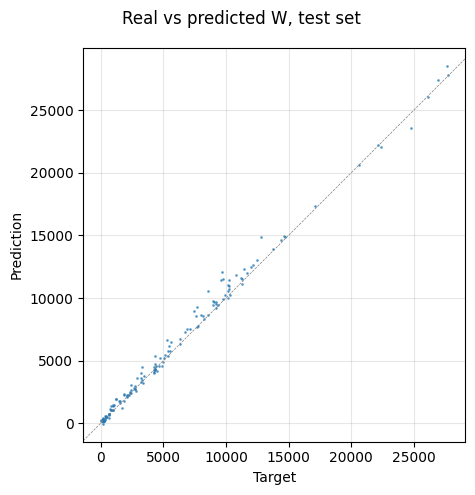

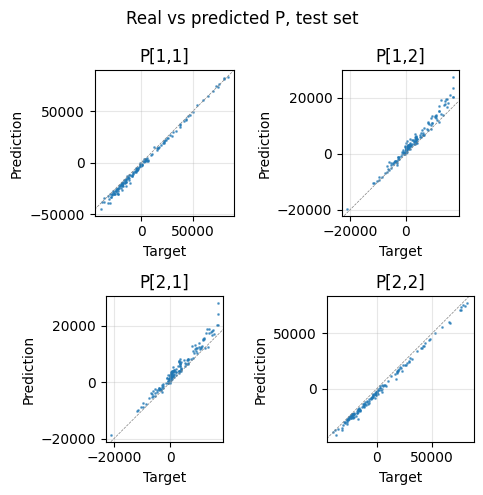

In [ ]:
# ------------------------------------------------------------------
# Cross-plots: predicted P, W versus target P, W on the test set.
# ------------------------------------------------------------------

# Plot W

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(targets_unscaled[:, -1], preds_unscaled[:, -1], s=1, alpha=0.6)
ax.axline([0,0], slope=1, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Target')
ax.set_ylabel('Prediction')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
fig.suptitle('Real vs predicted W, test set')
plt.tight_layout()
plt.show()

# Plot P

fig, axes = plt.subplots(2, 2, figsize=(5, 5))
for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        target_component = targets_P_unscaled[:, i, j].detach().cpu().numpy()
        prediction_component = preds_P_unscaled[:, i, j].detach().cpu().numpy()

        ax.scatter(target_component, prediction_component, s=1, alpha=0.6)
        ax.axline([0,0], slope=1, color='gray', linestyle='--', linewidth=0.5)

        ax.set_title(f'P[{i+1},{j+1}]')
        ax.set_xlabel('Target')
        ax.set_ylabel('Prediction')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

fig.suptitle('Real vs predicted P, test set')
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------------
# Evaluate the trained model on the test set. Compute S = dW/dE using autodifferentiation.
# ------------------------------------------------------------------
model.eval()
test_loss_sum = 0.0

dW_dE = []
target_S = []
pred_S = []

for batch in test_loader:
    inputs = batch[:, 0:3].requires_grad_(True)  # we need gradients with respect to E to compute dW/dE
    target = batch[:, 3:7]

    pred = model(inputs)
    loss = criterion(pred, target)

    pred_W = pred[:, -1]*std[:, 6] + mean[:, 6]  # unscale W

    pred_W.backward(torch.ones_like(pred_W))  # compute dW/dE_scaled using autodiff
    dW_dE_temp = inputs.grad / std[:, 0:3]  # unscale the gradient to get dW/dE in original physical units, using the chain rule: dW/dE = dW/dE_scaled * dE_scaled/dE = dW/dE_scaled / std_E

    # For symmetric tensors, the off-diagonal components get a factor of 2 from the constraint dE_12 = dE_21
    # So we divide by 2 to recover the true stress components
    dW_dE_temp[:, -1] = dW_dE_temp[:, -1] / 2.0
    dW_dE.append(dW_dE_temp)

    pred_S.append(pred[:, :3] * std[:, 3:6] + mean[:, 3:6])  # store the predicted S (scaled)

    target_S.append(target[:, :3] * std[:, 3:6] + mean[:, 3:6])  # unscale target S

dW_dE = torch.cat(dW_dE, dim=0)[:, [[0, 2], [2, 1]]]
target_S = torch.cat(target_S, dim=0)[:, [[0, 2], [2, 1]]]  # convert from compact vector form back to full tensor form
pred_S = torch.cat(pred_S, dim=0)
pred_S = pred_S[:, [[0, 2], [2, 1]]]  # convert from compact vector form back to full tensor form

MSE_S = ((dW_dE - target_S) ** 2).mean()
RMSE_S = torch.sqrt(MSE_S)

print('MSE of S=dW/dE on test set:', MSE_S.item())
print('RMSE of S=dW/dE on test set:', RMSE_S.item())

MSE_S = ((pred_S - target_S) ** 2).mean()
RMSE_S = torch.sqrt(MSE_S)

print('MSE of directly predicted S on test set:', MSE_S.item())
print('RMSE of directly predicted S on test set:', RMSE_S.item())

MSE of S=dW/dE on test set: 51608424.0
RMSE of S=dW/dE on test set: 7183.900390625
MSE of directly predicted S on test set: 29478714.0
RMSE of directly predicted S on test set: 5429.43017578125


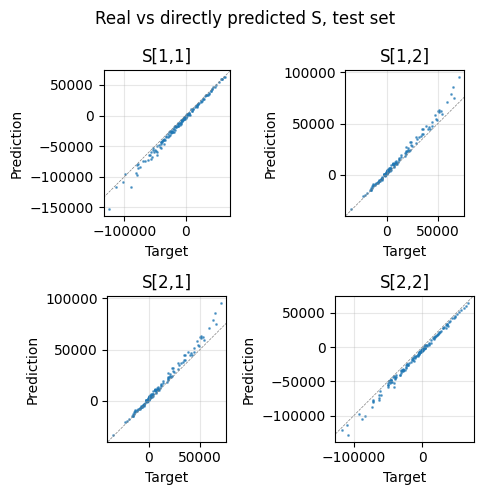

In [ ]:
# ------------------------------------------------------------------
# Cross-plots: directly predicted S versus target S on the test set.
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(5, 5))
for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        target_component = target_S[:, i, j].detach().cpu().numpy()
        prediction_component = pred_S[:, i, j].detach().cpu().numpy()

        ax.scatter(target_component, prediction_component, s=1, alpha=0.6)
        ax.axline([0,0], slope=1, color='gray', linestyle='--', linewidth=0.5)

        ax.set_title(f'S[{i+1},{j+1}]')
        ax.set_xlabel('Target')
        ax.set_ylabel('Prediction')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

fig.suptitle('Real vs directly predicted S, test set')
plt.tight_layout()
plt.show()

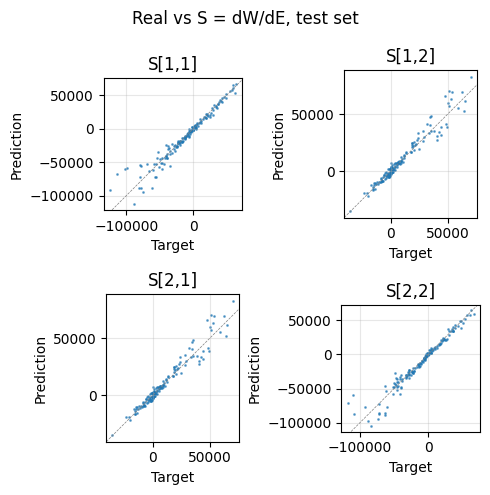

In [ ]:
# ------------------------------------------------------------------
# Cross-plots: S obtained from autodiff (dW/dE) versus target S on the test set.
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(5, 5))
for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        target_component = target_S[:, i, j].detach().cpu().numpy()
        prediction_component = dW_dE[:, i, j].detach().cpu().numpy()

        ax.scatter(target_component, prediction_component, s=1, alpha=0.6)
        ax.axline([0,0], slope=1, color='gray', linestyle='--', linewidth=0.5)

        ax.set_title(f'S[{i+1},{j+1}]')
        ax.set_xlabel('Target')
        ax.set_ylabel('Prediction')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

fig.suptitle('Real vs S = dW/dE, test set')
plt.tight_layout()
plt.show()

In [ ]:

# Code: directly train and do the whole thing. I will later remove some parts for students to fill in. use the same plotting as above also here. This case should presumably be more accurate. Demonstrate that requirement of S = dW/dE is not necessarily satisfied.

# --> It's kind of satisfied, but worse than predicting it directly. Also, using S instead of P actually gives worse results currently, but I suspect that is because this network also has to predict W.

### $^\star$ Exercise 2.3

Notice that in the previous Exercise 2.2, the relationship
$$
\boldsymbol{S}(\boldsymbol{E}) = \frac{\partial W(\boldsymbol{E})}{\partial\boldsymbol{E}}
$$
was not necessarily guaranteed by the trained NN. Ensuring that the above differential relationship holds can be achieved by penalizing the difference between the two expressions, i.e., adding the difference $\boldsymbol{S}-\frac{\partial W(\boldsymbol{E})}{\partial\boldsymbol{E}}$ into the loss function through, e.g., $\ell_2$ norm. Such a strategy is called Sobolev training, and will be exercised here.

#### Summary of results:
* RMSE of directly predicted S on test set: 5429.43017578125
* RMSE of S=dW/dE on test set: 7183.900390625
* RMSE of S=dW/dE, Sobolev trained: 4936.887695
So Sobolev is only slightly better than direct prediction (in this case)

In [ ]:
# Sobolev training: enforce the relationship S = dW/dE by penalizing the difference between
# the true S and S obtained from dW_pred/dE.
#
# The loss function becomes:
#     loss = MSE(W_pred, W_target) + lambda * MSE(dW_pred/dE - S_target)
#
# This ensures that the network learns W such that its derivative w.r.t. E matches the true S.

# ------------------------------------------------------------------
# Re-initialize model and optimizer for Sobolev training
# ------------------------------------------------------------------
input_dim = 3
output_dim = 1  # only W
hidden_dim = 64

model_sobolev = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, output_dim),
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_sobolev.parameters(), lr=1e-3)

sobolev_weight = 1.0  # weight of the Sobolev penalty term

train_loss_history_W = []
val_loss_history_W = []
train_loss_history_S = []
val_loss_history_S = []

# ------------------------------------------------------------------
# Training loop with Sobolev penalty
# ------------------------------------------------------------------
for epoch in range(num_epochs):
    model_sobolev.train()
    train_loss_W_sum = 0.0
    train_loss_S_sum = 0.0

    # Train on all training data
    for batch in train_loader:
        inputs = batch[:, 0:3].detach().requires_grad_(True)
        targets = batch[:, 3:7]

        S_target = targets[:, :3]  # true S (scaled)
        W_target = targets[:, -1]  # true W (scaled)

        pred_W = model_sobolev(inputs).squeeze(-1)

        # MSE loss on W prediction
        mse_loss = criterion(pred_W, W_target)

        # Sobolev penalty: compute dW/dE via autodiff and compare with true S
        dW_dE_scaled = torch.autograd.grad(
            outputs=pred_W,
            inputs=inputs,
            grad_outputs=torch.ones_like(pred_W),
            create_graph=True,
            retain_graph=True,
        )[0]

        # Unscale the gradient: dW/dE = dW/dE_scaled / std_E * std_W (chain rule)
        dW_dE_unscaled = dW_dE_scaled / std[:, 0:3] * std[:, [6]]

        # Divide off-diagonal component by 2 (symmetric tensor constraint)
        dW_dE_unscaled[:, -1] = dW_dE_unscaled[:, -1] / 2.0

        # Sobolev loss: penalize difference between dW/dE and true S
        sobolev_loss = criterion((dW_dE_unscaled - mean[:, 3:6]) / std[:, 3:6], S_target)

        # Total loss: combine W loss with Sobolev penalty
        total_loss = mse_loss + sobolev_weight * sobolev_loss

        # Update model
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        train_loss_W_sum += mse_loss.item() * inputs.shape[0]
        train_loss_S_sum += sobolev_loss.item() * inputs.shape[0]

    mean_train_loss_W = train_loss_W_sum / len(train_loader.dataset)
    mean_train_loss_S = train_loss_S_sum / len(train_loader.dataset)
    train_loss_history_W.append(mean_train_loss_W)
    train_loss_history_S.append(mean_train_loss_S)

    # Validation
    model_sobolev.eval()
    val_loss_W_sum = 0.0
    val_loss_S_sum = 0.0

    for batch in val_loader:
        inputs = batch[:, 0:3].detach().requires_grad_(True)
        targets = batch[:, 3:7]

        S_target = targets[:, :3]  # true S (scaled)
        W_target = targets[:, -1]  # true W (scaled)

        pred_W = model_sobolev(inputs).squeeze(-1)

        # MSE loss on W prediction
        mse_loss = criterion(pred_W, W_target)

        # Sobolev penalty for validation (no create_graph needed)
        dW_dE_scaled = torch.autograd.grad(
            outputs=pred_W,
            inputs=inputs,
            grad_outputs=torch.ones_like(pred_W),
            create_graph=False,
            retain_graph=False,
        )[0]

        # Unscale the gradient: dW/dE = dW/dE_scaled / std_E * std_W (chain rule)
        dW_dE_unscaled = dW_dE_scaled / std[:, 0:3] * std[:, [6]]

        # Divide off-diagonal component by 2 (symmetric tensor constraint)
        dW_dE_unscaled[:, -1] = dW_dE_unscaled[:, -1] / 2.0

        # Sobolev loss: penalize difference between dW/dE and true S
        sobolev_loss = criterion((dW_dE_unscaled - mean[:, 3:6]) / std[:, 3:6], S_target)

        val_loss_W_sum += mse_loss.item() * inputs.shape[0]
        val_loss_S_sum += sobolev_loss.item() * inputs.shape[0]

    mean_val_loss_W = val_loss_W_sum / len(val_loader.dataset)
    mean_val_loss_S = val_loss_S_sum / len(val_loader.dataset)
    val_loss_history_W.append(mean_val_loss_W)
    val_loss_history_S.append(mean_val_loss_S)

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(
            f'Epoch {epoch + 1:3d}/{num_epochs} | '
            f'train loss:  W {mean_train_loss_W:.6f}, S {mean_train_loss_S:.6f} | '
            f'val loss:  W {mean_val_loss_W:.6f}, S {mean_val_loss_S:.6f}'
        )


Epoch   1/100 | train loss:  W 0.969554, S 1.075835 | val loss:  W 0.855823, S 0.607872
Epoch  10/100 | train loss:  W 0.039383, S 0.455499 | val loss:  W 0.034687, S 0.122399
Epoch  20/100 | train loss:  W 0.011759, S 0.226555 | val loss:  W 0.009243, S 0.045533
Epoch  30/100 | train loss:  W 0.004712, S 0.127840 | val loss:  W 0.006908, S 0.045635
Epoch  40/100 | train loss:  W 0.002862, S 0.076236 | val loss:  W 0.002257, S 0.022212
Epoch  50/100 | train loss:  W 0.002381, S 0.058531 | val loss:  W 0.002656, S 0.022568
Epoch  60/100 | train loss:  W 0.003104, S 0.050534 | val loss:  W 0.002701, S 0.018095
Epoch  70/100 | train loss:  W 0.001310, S 0.018699 | val loss:  W 0.001537, S 0.016107
Epoch  80/100 | train loss:  W 0.001007, S 0.025150 | val loss:  W 0.001594, S 0.013174
Epoch  90/100 | train loss:  W 0.000916, S 0.015044 | val loss:  W 0.001434, S 0.013493
Epoch 100/100 | train loss:  W 0.001143, S 0.028327 | val loss:  W 0.001783, S 0.013173


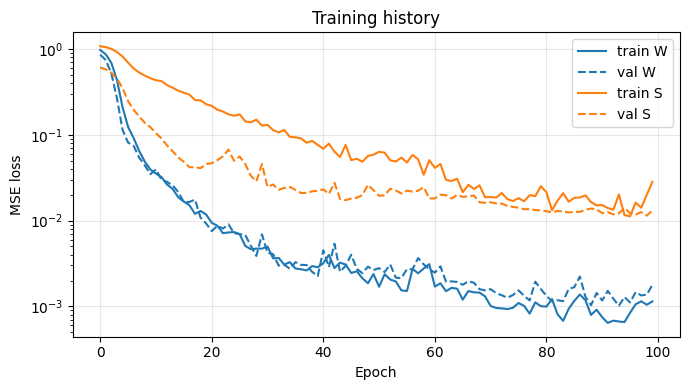

In [ ]:
# Plot 1: Training history comparison
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(train_loss_history_W, label='train W', linestyle='-', color='tab:blue')
ax.plot(val_loss_history_W, label='val W', linestyle='--', color='tab:blue')
ax.plot(train_loss_history_S, label='train S', linestyle='-', color='tab:orange')
ax.plot(val_loss_history_S, label='val S', linestyle='--', color='tab:orange')

ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_yscale('log')
ax.set_title('Training history')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Evaluate Sobolev-trained model on the test set
# Extract S_pred from dW_pred/dE and compare with true S
# ------------------------------------------------------------------
model_sobolev.eval()

W_preds_sobolev = []
S_preds_sobolev = []
W_targets = []
S_targets = []

for batch in test_loader:
    inputs = batch[:, 0:3].detach().requires_grad_(True)
    targets = batch[:, 3:7]

    S_target = targets[:, :3]
    W_target = targets[:, -1]

    pred_W = model_sobolev(inputs).squeeze(-1)

    # Compute S = dW/dE via autodiff
    dW_dE = torch.autograd.grad(
        outputs=pred_W,
        inputs=inputs,
        grad_outputs=torch.ones_like(pred_W),
        create_graph=False,
        retain_graph=False,
    )[0]

    # Unscale gradient to physical units
    dW_dE = dW_dE / std[:, 0:3] * std[:, [6]]
    dW_dE[:, -1] = dW_dE[:, -1] / 2.0  # symmetric tensor constraint

    W_preds_sobolev.append(pred_W.detach())
    S_preds_sobolev.append(dW_dE.detach())
    W_targets.append(W_target)
    S_targets.append(S_target)

W_preds_sobolev = torch.cat(W_preds_sobolev, dim=0)
S_preds_sobolev = torch.cat(S_preds_sobolev, dim=0)
W_targets = torch.cat(W_targets, dim=0)
S_targets = torch.cat(S_targets, dim=0)

# Unscale for comparison
W_preds_unscaled = W_preds_sobolev * std[:, 6] + mean[:, 6]
S_preds_unscaled = S_preds_sobolev  # already unscaled
W_targets_unscaled = W_targets * std[:, 6] + mean[:, 6]
S_targets_unscaled = S_targets * std[:, 3:6] + mean[:, 3:6]

MSE_S_sobolev = ((S_preds_unscaled - S_targets_unscaled) ** 2).mean()
MSE_W_sobolev = ((W_preds_unscaled - W_targets_unscaled) ** 2).mean()
RMSE_S_sobolev = torch.sqrt(MSE_S_sobolev)
RMSE_W_sobolev = torch.sqrt(MSE_W_sobolev)

print('Sobolev Model - Test Set Performance:')
print(f'MSE of W: {MSE_W_sobolev.item():.6f}')
print(f'RMSE of W: {RMSE_W_sobolev.item():.6f}')
print(f'MSE of S (derived from dW/dE): {MSE_S_sobolev.item():.6f}')
print(f'RMSE of S (derived from dW/dE): {RMSE_S_sobolev.item():.6f}')


Sobolev Model - Test Set Performance:
MSE of W: 69038.085938
RMSE of W: 262.751007
MSE of S (derived from dW/dE): 24372862.000000
RMSE of S (derived from dW/dE): 4936.887695


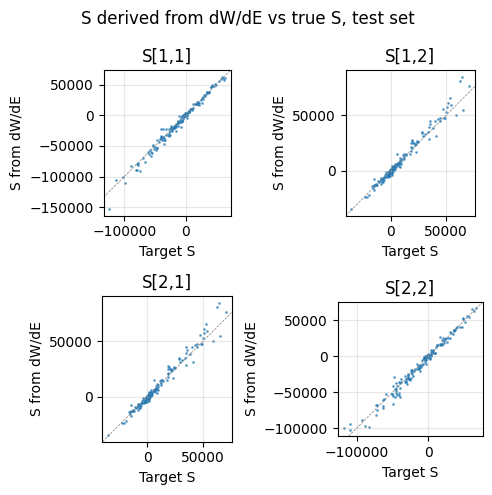

In [ ]:
# ------------------------------------------------------------------
# Visualization: compare Exercise 2.2 vs Exercise 2.3
# ------------------------------------------------------------------
# Plot 3: Cross-plot of S for Exercise 2.3 (derived from dW/dE)
# S_targets and S_preds_unscaled are in compact form [S11, S22, S12]
# Reshape to [2,2] tensor form for plotting
S_targets_tensor = S_targets_unscaled[:, [[0, 2], [2, 1]]]
S_preds_tensor = S_preds_unscaled[:, [[0, 2], [2, 1]]]

fig, axes = plt.subplots(2, 2, figsize=(5, 5))
for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        target_component = S_targets_tensor[:, i, j].detach().cpu().numpy()
        prediction_component = S_preds_tensor[:, i, j].detach().cpu().numpy()

        ax.scatter(target_component, prediction_component, s=1, alpha=0.6)
        ax.axline([0,0], slope=1, color='gray', linestyle='--', linewidth=0.5)

        ax.set_title(f'S[{i+1},{j+1}]')
        ax.set_xlabel('Target S')
        ax.set_ylabel('S from dW/dE')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

fig.suptitle('S derived from dW/dE vs true S, test set')
plt.tight_layout()
plt.show()


## 3. Effective (micro-)structure versus property relationships

Consider a family of pixelized microstructures, examples of which are provided in the figure below. The dataset contains for each of the microstructures several microstructural field quantities represented on a pixelized grid. Here white means material ($\rho(\vec{X}) = 0$) and black void ($\rho(\vec{X}) = 1$). The entire domain (picture) is a Representative Volume Element (RVE) $\Omega$. Recall that for first-order computational homogenization the following kinematic decomposition ansatz is used, implying the dependence of the microstructural deformation gradient tensor $\boldsymbol{F}$ on the macrostructural deformation gradient tensor $\boldsymbol{\overline{\boldsymbol{F}}}$, i.e.,
$$
\boldsymbol{F}(\overline{\boldsymbol{F}},\rho(\vec{X}),\vec{X}) = \overline{\boldsymbol{F}} + (\vec{\nabla}\vec{w}(\overline{\boldsymbol{F}},\rho(\vec{X}),\vec{X}))^\mathsf{T},
$$
where $\vec{w}$ is the periodic microfluctuation field dependent on the macrostructural deformation gradient (RVE loading), the underlying microstructural geometry, and microstructual material point position. From the homogenization theory we can write homogenized quantities using the averaging relationships as
$$
\overline{W}(\overline{\boldsymbol{F}},\rho) = \frac{1}{|\Omega|}\int_\Omega W(\boldsymbol{F},\rho,\vec{X}) \, \mathrm{d}\vec{X},
$$
$$
\overline{\boldsymbol{P}}(\overline{\boldsymbol{F}},\rho) = \frac{1}{|\Omega|}\int_\Omega \boldsymbol{P}(\boldsymbol{F},\rho,\vec{X}) \, \mathrm{d}\vec{X},
$$
$$
^4\overline{\boldsymbol{C}}(\overline{\boldsymbol{F}},\rho)
= \frac{\partial\overline{\boldsymbol{P}}(\overline{\boldsymbol{F}},\rho)}{\partial\overline{\boldsymbol{F}}}
= \frac{1}{|\Omega|}\int_\Omega \frac{\partial \boldsymbol{P}(\boldsymbol{F},\rho,\vec{X})}{\partial\overline{\boldsymbol{F}}} \, \mathrm{d}\vec{X}
= \frac{1}{|\Omega|}\int_\Omega \frac{\partial \boldsymbol{P}(\boldsymbol{F},\rho,\vec{X})}{\partial{\boldsymbol{F}}} \frac{\partial\boldsymbol{F}}{\partial\overline{\boldsymbol{F}}} \, \mathrm{d}\vec{X}
= \frac{1}{|\Omega|}\int_\Omega {^4\boldsymbol{C}}(\boldsymbol{F},\rho,\vec{X}) \left( \frac{\partial\overline{\boldsymbol{F}}}{\partial\overline{\boldsymbol{F}}} + \frac{\partial(\vec{\nabla}\vec{w}(\overline{\boldsymbol{F}},\rho(\vec{X}),\vec{X}))^\mathsf{T}}{\partial\overline{\boldsymbol{F}}} \right) \, \mathrm{d}\vec{X},
$$
where the macroscopic quantities are indicated with over-bars ($\overline{\bullet}$), while the microstructural quantities without them. Notice that the effective stiffness requires knowledge of the sensitivities of the gradient of the microstructural field $\vec{w}$ with respect to the changes in components of the macrostructural deformation gradient $\overline{\boldsymbol{F}}$. This in turn requires solution of the governing underlying RVE partial differential equation ($\vec{\nabla}_0\cdot\boldsymbol{P}^\mathsf{T} = \vec{0}$), which implies that obtaining $^4\overline{\boldsymbol{C}}$ is not trivial.

### Exercise 3.1

For simplicity, let us consider only the reference configuration, i.e., adopt in the above equations $\overline{\boldsymbol{F}} = \boldsymbol{I}$. This implies that $\overline{W} = 0$ and $\overline{\boldsymbol{P}} = \boldsymbol{0}$, the effective stiffness $^4\overline{\boldsymbol{C}}(\boldsymbol{I},\rho)$ being the only non-zero quantity, expressed as a function of the density field $\rho$.

Using a Convolutional Neural Network (CNN), learn the corresponding structure-property map between the material density $\rho(\vec{X})$ and the corresponding effective RVE stiffness $^4\overline{\boldsymbol{C}}$, i.e., $^4\overline{\boldsymbol{C}} \approx \mathsf{CNN}(\rho)$.

In [ ]:
# Open microstructure dataset
micro_data = torch.load('microstructures.pt')
X = micro_data['imgs'].to(torch.float32)
y = micro_data['C_macro'].to(torch.float32)
num_samples = X.shape[0]
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Number of samples: {num_samples}')

y_flat = y.reshape(num_samples, 4, 4)
y_flat = y_flat[:, [0, 0, 0, 1, 1, 3], [0, 1, 1, 2, 2, 2]]  # extract unique components of the stiffness tensor
print(f'y_flat shape: {y_flat.shape}')

X shape: torch.Size([2998, 64, 64])
y shape: torch.Size([2998, 2, 2, 2, 2])
Number of samples: 2998
y_flat shape: torch.Size([2998, 6])


In [ ]:
# Extract the 6 unique components of the stiffness tensor
uniq_comps = [[0, 0, 0, 0],  # C_0000
              [0, 0, 0, 1],  # C_0001
              [0, 0, 1, 1],  # C_0011
              [0, 1, 0, 1],  # C_0101
              [1, 1, 0, 1],  # C_1101
              [1, 1, 1, 1]]  # C_1111
uniq_comps = torch.tensor(uniq_comps)

y_flat = y[:, uniq_comps[:, 0], uniq_comps[:, 1], uniq_comps[:, 2], uniq_comps[:, 3]]  # extract unique

print(y_flat.shape)

torch.Size([2998, 6])


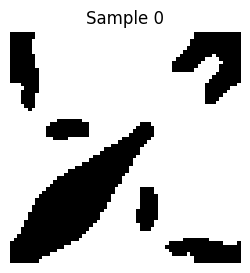

C_macro:
tensor([[[[296.5979, -94.4803],
          [-94.4803,  95.2175]],

         [[-94.4803, 118.3393],
          [118.3393, -82.1967]]],


        [[[-94.4803, 118.3393],
          [118.3393, -82.1967]],

         [[ 95.2175, -82.1967],
          [-82.1967, 215.1843]]]])
tensor([296.5979, -94.4803,  95.2175, 118.3393, -82.1967, 215.1843])


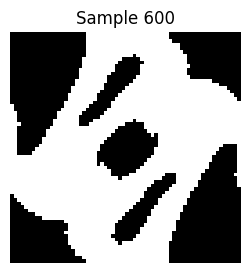

C_macro:
tensor([[[[ 70.1598,  20.1621],
          [ 20.1621,  41.4662]],

         [[ 20.1621,  61.5703],
          [ 61.5703,   8.8917]]],


        [[[ 20.1621,  61.5703],
          [ 61.5703,   8.8917]],

         [[ 41.4662,   8.8917],
          [  8.8917, 232.4608]]]])
tensor([ 70.1598,  20.1621,  41.4662,  61.5703,   8.8917, 232.4608])


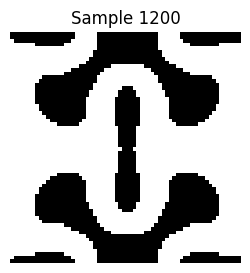

C_macro:
tensor([[[[ 55.9337,  -3.3345],
          [ -3.3345,   9.1328]],

         [[ -3.3345,  16.6922],
          [ 16.6922, -12.9935]]],


        [[[ -3.3345,  16.6922],
          [ 16.6922, -12.9935]],

         [[  9.1328, -12.9935],
          [-12.9935,  64.7046]]]])
tensor([ 55.9337,  -3.3345,   9.1328,  16.6922, -12.9935,  64.7046])


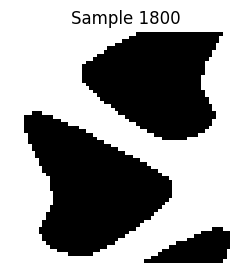

C_macro:
tensor([[[[216.4939,   3.5087],
          [  3.5087, 112.5158]],

         [[  3.5087,  83.0047],
          [ 83.0047,  -2.9457]]],


        [[[  3.5087,  83.0047],
          [ 83.0047,  -2.9457]],

         [[112.5158,  -2.9457],
          [ -2.9457, 313.1092]]]])
tensor([216.4939,   3.5087, 112.5158,  83.0047,  -2.9457, 313.1092])


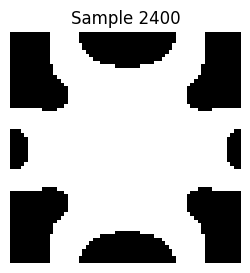

C_macro:
tensor([[[[ 3.2977e+02, -2.1691e-01],
          [-2.1691e-01,  5.7047e+01]],

         [[-2.1691e-01,  2.8144e+01],
          [ 2.8144e+01, -3.4021e-02]]],


        [[[-2.1691e-01,  2.8144e+01],
          [ 2.8144e+01, -3.4021e-02]],

         [[ 5.7047e+01, -3.4021e-02],
          [-3.4021e-02,  2.5074e+02]]]])
tensor([ 3.2977e+02, -2.1691e-01,  5.7047e+01,  2.8144e+01, -3.4021e-02,
         2.5074e+02])


In [ ]:
# Show some example microstructures and their stiffness tensors.
for i in range(0, 3000, 600):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(X[i].cpu(), cmap='gray')
    ax.set_title(f'Sample {i}')
    ax.axis('off')
    plt.show()
    print('C_macro:')
    print(y[i])
    print(y_flat[i])

In [ ]:
# Split into train/val/test (70/15/15)
train_ratio = 0.7
val_ratio = 0.15

train_size = int(train_ratio * num_samples)
val_size = int(val_ratio * num_samples)

split_seed = 42
generator = torch.Generator().manual_seed(split_seed)
indices = torch.randperm(num_samples, generator=generator)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_train, y_val, y_test = y_flat[train_idx], y_flat[val_idx], y_flat[test_idx]

# Normalize using train statistics only.
X_mean = X_train.mean()
X_std = X_train.std().clamp_min(1e-8)
y_mean = y_train.mean(dim=0, keepdim=True)
y_std = y_train.std(dim=0, keepdim=True).clamp_min(1e-8)

X_train_scaled = (X_train - X_mean) / X_std
X_val_scaled = (X_val - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

# Create dataloaders
batch_size = 32

train_dataset = TensorDataset(X_train_scaled, y_train_scaled)
val_dataset = TensorDataset(X_val_scaled, y_val_scaled)
test_dataset = TensorDataset(X_test_scaled, y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'X shape: {X.shape}, y shape: {y_flat.shape}')
print(f'Splits: train {len(train_dataset)}, val {len(val_dataset)}, test {len(test_dataset)}')

x_batch, y_batch = next(iter(train_loader))
print(f'Example batch shapes: X {x_batch.shape}, y {y_batch.shape}')

X shape: torch.Size([2998, 64, 64]), y shape: torch.Size([2998, 6])
Splits: train 2098, val 449, test 451
Example batch shapes: X torch.Size([32, 64, 64]), y torch.Size([32, 6])


In [ ]:
# For his, we recommend using a GPU with CUDA for fasting training. In CoLab, you can enable GPU acceleration by going to "Runtime" -> "Change runtime type" and selecting a GPU or TPU as the hardware accelerator.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


In [ ]:
# Simple CNN baseline: microstructure image -> 6 unique components of C_macro

num_targets = 6

cnn_model = nn.Sequential(                       # In:  [B, 64, 64, 1]
    nn.Conv2d(1, 16, kernel_size=3, padding=1),  # [B, 64, 64, 16]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),                 # [B, 32, 32, 16]
    nn.Conv2d(16, 32, kernel_size=3, padding=1), # [B, 32, 32, 32]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),                 # [B, 16, 16, 32]
    nn.Conv2d(32, 64, kernel_size=3, padding=1), # [B, 16, 16, 64]
    nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),                # [B, 1, 1, 64]
    nn.Flatten(),                                # [B, 64]
    nn.Linear(64, 64),                           # [B, 64]
    nn.ReLU(),
    nn.Linear(64, num_targets),                  # [B, 6]
).to(device)


In [ ]:
# takes approx 2-3 minutes on a laptop GPU.

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
num_epochs = 200

train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    cnn_model.train()
    train_loss_sum = 0.0

    for xb, yb in train_loader:
        # Add channel dimension if input is [B, H, W]
        if xb.ndim == 3:
            xb = xb.unsqueeze(1)
        xb = xb.to(device)
        yb = yb.to(device)

        pred = cnn_model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.shape[0]

    mean_train_loss = train_loss_sum / len(train_loader.dataset)
    train_loss_history.append(mean_train_loss)

    cnn_model.eval()
    val_loss_sum = 0.0
    with torch.inference_mode():
        for xb, yb in val_loader:
            if xb.ndim == 3:
                xb = xb.unsqueeze(1)
            xb = xb.to(device)
            yb = yb.to(device)

            pred = cnn_model(xb)
            loss = criterion(pred, yb)
            val_loss_sum += loss.item() * xb.shape[0]

    mean_val_loss = val_loss_sum / len(val_loader.dataset)
    val_loss_history.append(mean_val_loss)

    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(
            f'Epoch {epoch + 1:3d}/{num_epochs} | '
            f'train loss = {mean_train_loss:.6f} | '
            f'val loss = {mean_val_loss:.6f}'
        )


Epoch   1/200 | train loss = 0.790746 | val loss = 0.719842
Epoch   5/200 | train loss = 0.394600 | val loss = 0.417589
Epoch  10/200 | train loss = 0.330136 | val loss = 0.335149
Epoch  15/200 | train loss = 0.279638 | val loss = 0.286577
Epoch  20/200 | train loss = 0.267831 | val loss = 0.260918
Epoch  25/200 | train loss = 0.239746 | val loss = 0.240731
Epoch  30/200 | train loss = 0.209699 | val loss = 0.221449
Epoch  35/200 | train loss = 0.194251 | val loss = 0.201322
Epoch  40/200 | train loss = 0.187348 | val loss = 0.189871
Epoch  45/200 | train loss = 0.173201 | val loss = 0.186026
Epoch  50/200 | train loss = 0.163296 | val loss = 0.190319
Epoch  55/200 | train loss = 0.156181 | val loss = 0.168042
Epoch  60/200 | train loss = 0.156058 | val loss = 0.171327
Epoch  65/200 | train loss = 0.145303 | val loss = 0.168694
Epoch  70/200 | train loss = 0.145045 | val loss = 0.163730
Epoch  75/200 | train loss = 0.143653 | val loss = 0.160794
Epoch  80/200 | train loss = 0.132749 | 

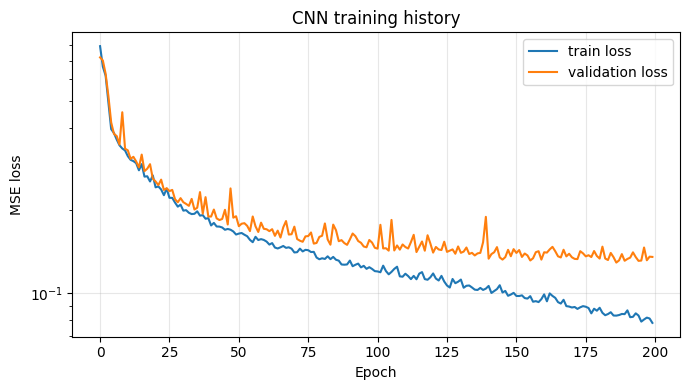

In [ ]:
# Plot training history
plt.figure(figsize=(7, 4))
plt.plot(train_loss_history, label='train loss')
plt.plot(val_loss_history, label='validation loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('CNN training history')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Test evaluation
cnn_model.eval()
test_loss_sum = 0.0
preds_scaled = []
targets_scaled = []

with torch.inference_mode():
    for xb, yb in test_loader:
        if xb.ndim == 3:
            xb = xb.unsqueeze(1)
        xb = xb.to(device)
        yb = yb.to(device)

        pred = cnn_model(xb)
        loss = criterion(pred, yb)

        test_loss_sum += loss.item() * xb.shape[0]
        preds_scaled.append(pred.cpu())
        targets_scaled.append(yb.cpu())

mean_test_loss = test_loss_sum / len(test_loader.dataset)
print(f'Final test loss (scaled) = {mean_test_loss:.6f}')

preds_scaled = torch.cat(preds_scaled, dim=0)
targets_scaled = torch.cat(targets_scaled, dim=0)

# Convert back to physical units using training-set stats
preds_unscaled = preds_scaled * y_std + y_mean
targets_unscaled = targets_scaled * y_std + y_mean

rmse_phys = torch.sqrt(((preds_unscaled - targets_unscaled) ** 2).mean())
print(f'RMSE in physical units = {rmse_phys.item():.6f}')

Final test loss (scaled) = 0.143712
RMSE in physical units = 41.033375


In [ ]:
# map back to full 2x2x2x2 stiffness tensor form for plotting
# [A, B, B, C]
# [B, D, D, E]
# [B, D, D, E]
# [C, E, E, F]

C_pred = preds_unscaled[:, [[0, 1, 1, 2],[1, 3, 3, 4], [1, 3, 3, 4], [2, 4, 4, 5]]].reshape(-1, 2, 2, 2, 2)
C_targ = targets_unscaled[:, [[0, 1, 1, 2],[1, 3, 3, 4], [1, 3, 3, 4], [2, 4, 4, 5]]].reshape(-1, 2, 2, 2, 2)

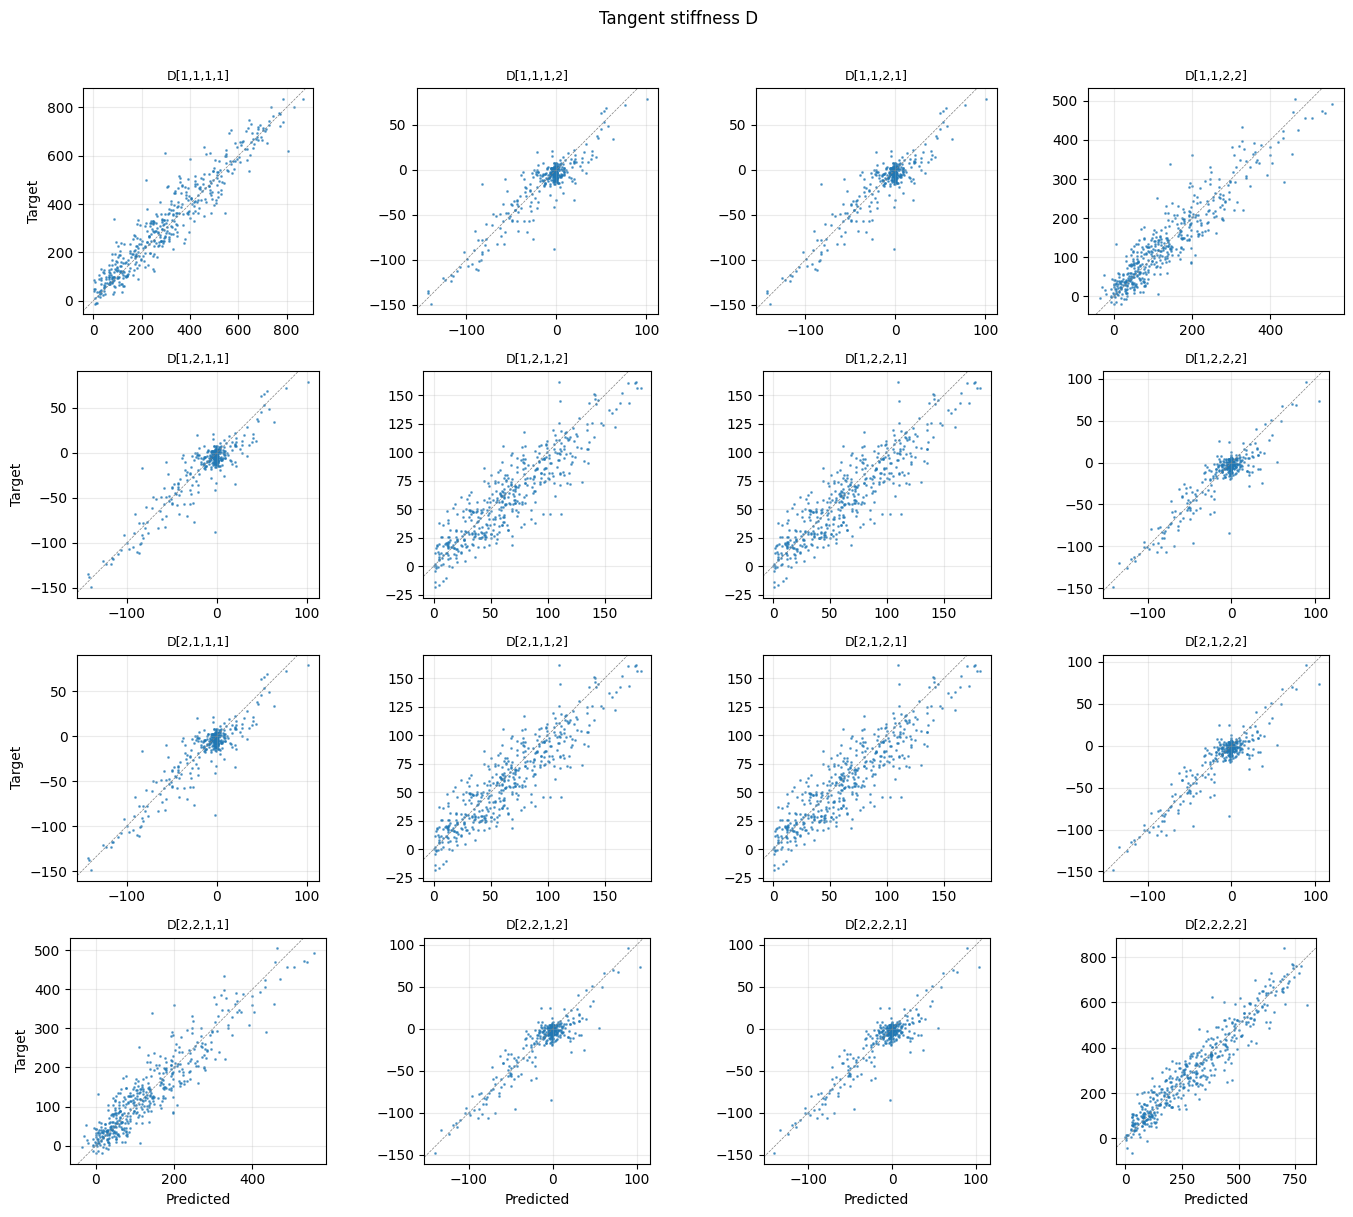

In [ ]:
# Plot 3: D components (4x4 grid)
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
for i in range(2):
    for j in range(2):
        for k in range(2):
            for l in range(2):
                a = i*2 + j
                b = k*2 + l
                ax = axes[a, b]
                ax.scatter(C_targ[:, i, j, k, l], C_pred[:, i, j, k, l], s=1, alpha=0.6)
                ax.set_title(f'D[{i+1},{j+1},{k+1},{l+1}]', fontsize=9)
                ax.grid(True, alpha=0.25)
                if a == 3:
                    ax.set_xlabel('Predicted')
                if b == 0:
                    ax.set_ylabel('Target')

                ax.axline([0,0], slope=1, color='gray', linestyle='--', linewidth=0.5)

                ax.set_aspect('equal')

fig.suptitle('Tangent stiffness D', y=1.01)
plt.tight_layout()
plt.show()

## Review

Multilayer Perceptrons (MLP) and Convolutional Neural Networks (CNN) are a useful concept for regressing multidimensional functions, including constitutive laws present in solid mechanics.
You have seen the main steps present in training and using any neural network, including handling of data and their split into training and validation, initialization of a neural network, creating a forward pass and architecture of the network, as well as the backpropagation, update step and iterative repetition to achieve gradual training.
You have experimented with two types of networks that are better or worse suited for different tasks, and touched on promoting certain type of behaviour (differential relationships promoted through Sobolev training).

At this point you should have developed some understanding of the concepts behind MLP and CNN regressions and their training.